In [1]:
!git clone https://github.com/facebookresearch/segment-anything.git
%cd segment-anything

!pip install -e .
!pip install opencv-python matplotlib

Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 18.31 MiB | 38.98 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/segment-anything
Obtaining file:///content/segment-anything
  Preparing metadata (setup.py) ... done
  Running setup.py develop for segment_anything


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="K66OYXtvYb56ZXv8k6eC")
project = rf.workspace("debotosh").project("drywall-join-detect-gkvkf")
version = project.version(4)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drywall-Join-Detect-4 in coco:: 100%|██████████| 2171/2171 [00:00<00:00, 7255.99it/s]


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="K66OYXtvYb56ZXv8k6eC")
project = rf.workspace("debotosh").project("cracks-3ii36-tekeg")
version = project.version(5)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cracks-5 in coco:: 100%|██████████| 8904/8904 [00:01<00:00, 5805.85it/s]


In [3]:
print(dataset.location)

/content/segment-anything/Drywall-Join-Detect-4


In [4]:
import json
import cv2
import numpy as np
import os

coco_path = "/content/segment-anything/cracks-5/train/_annotations.coco.json"
mask_dir = "/content/segment-anything/cracks-5/train_masks"


os.makedirs(mask_dir, exist_ok=True)

with open(coco_path) as f:
    coco = json.load(f)

# map images
images = {img["id"]: img for img in coco["images"]}

# group annotations
from collections import defaultdict
ann_dict = defaultdict(list)

for ann in coco["annotations"]:
    ann_dict[ann["image_id"]].append(ann)

# create masks
for img_id, anns in ann_dict.items():
    img_info = images[img_id]

    h, w = img_info["height"], img_info["width"]
    file_name = img_info["file_name"]

    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in anns:
        for seg in ann["segmentation"]:
            pts = np.array(seg).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)
    kernel = np.ones((9,9), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)


    cv2.imwrite(os.path.join(mask_dir, file_name), mask)

print(" Proper train_masks created!")

 Proper train_masks created!


In [5]:
import json
import cv2
import numpy as np
import os

coco_path = "/content/segment-anything/cracks-5/valid/_annotations.coco.json"
mask_dir = "/content/segment-anything/cracks-5/valid_masks"


os.makedirs(mask_dir, exist_ok=True)

with open(coco_path) as f:
    coco = json.load(f)

# map images
images = {img["id"]: img for img in coco["images"]}

# group annotations
from collections import defaultdict
ann_dict = defaultdict(list)

for ann in coco["annotations"]:
    ann_dict[ann["image_id"]].append(ann)

# create masks
for img_id, anns in ann_dict.items():
    img_info = images[img_id]

    h, w = img_info["height"], img_info["width"]
    file_name = img_info["file_name"]

    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in anns:
        for seg in ann["segmentation"]:
            pts = np.array(seg).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)
    kernel = np.ones((9,9), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)


    cv2.imwrite(os.path.join(mask_dir, file_name), mask)

print(" Proper valid_masks created!")

 Proper valid_masks created!


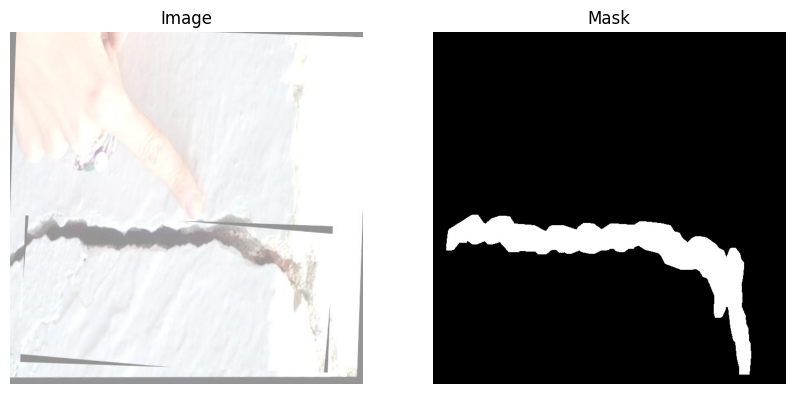

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

# paths
img_dir = "/content/segment-anything/cracks-5/train"
mask_dir = "/content/segment-anything/cracks-5/train_masks"

# pick one sample
file_name = os.listdir(mask_dir)[10]

# read image and mask
img = cv2.imread(os.path.join(img_dir, file_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(mask_dir, file_name), 0)

# plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()

In [7]:
!pip install segment-anything transformers timm opencv-python

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os

from segment_anything import sam_model_registry
from transformers import CLIPTextModel, CLIPTokenizer

In [8]:
class SegTextDataset(Dataset):
    def __init__(self, img_dir, mask_dir, prompt_list):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)
        self.prompts = prompt_list

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f" Image not found: {img_path}")
            return self.__getitem__((idx + 1) % len(self))  # skip bad sample

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (1024, 1024)) / 255.0

        mask_path = os.path.join(self.mask_dir, img_name)
        mask = cv2.imread(mask_path, 0)

        if mask is None:
            print(f" Mask not found: {mask_path}")
            return self.__getitem__((idx + 1) % len(self))
        mask = cv2.resize(mask, (1024, 1024))
        mask = (mask > 127).astype(np.float32)

        text = np.random.choice(self.prompts)
        return (
            torch.tensor(img).permute(2,0,1).float(),
            torch.tensor(mask).unsqueeze(0).float(),
            text,
            img_name
        )


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from segment_anything import sam_model_registry
from transformers import CLIPTextModel, CLIPTokenizer


class TextSAM(nn.Module):
    def __init__(self, sam_ckpt):
        super().__init__()

        # SAM
        self.sam = sam_model_registry["vit_b"](checkpoint=sam_ckpt)

        # Freeze image encoder (important)
        for p in self.sam.image_encoder.parameters():
            p.requires_grad = False

        # CLIP text encoder
        self.tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
        self.text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")

        for p in self.text_encoder.parameters():
            p.requires_grad = False
        for p in self.sam.mask_decoder.parameters():
            p.requires_grad = True
        # Projection to SAM prompt dim (256)
        self.proj = nn.Linear(512, 256)
        nn.init.xavier_uniform_(self.proj.weight)

    def forward(self, images, texts):
        device = images.device
        B = images.shape[0]

        # -----------------------------
        # 1. Image encoder (SAM)
        # -----------------------------
        image_embeddings = self.sam.image_encoder(images)  # (B, C, 64, 64)

        # -----------------------------
        # 2. Text encoding (CLIP)
        # -----------------------------
        tokens = self.tokenizer(
            texts,
            padding=True,
            return_tensors="pt"
        ).to(device)
        text_features = self.text_encoder(**tokens).pooler_output  # (B, 512)
        text_emb = self.proj(text_features)
        text_emb = F.normalize(text_emb, dim=-1)
        text_emb = 0.05 * text_emb                       # (B, 256)
        text_emb = text_emb.unsqueeze(1)                           # (B, 1, 256)

        # -----------------------------
        # 3. Get SAM prompt embeddings (base for a single image, will be used per image in loop)
        # -----------------------------
        # These are initially (1, 0, 256) for sparse and (1, 256, 64, 64) for dense
        initial_sparse_embeddings, initial_dense_embeddings = self.sam.prompt_encoder(
            points=None,
            boxes=None,
            masks=None
        )

        # The image positional encoding is also (1, 256, 64, 64)
        image_pe = self.sam.prompt_encoder.get_dense_pe() # (1, 256, 64, 64)

        # List to store results for each image in the batch
        batch_low_res_masks = []

        # Process each image in the batch individually
        for i in range(B):
            # Prepare sparse embeddings for the current image: expand base sparse and add text_emb
            current_sparse_embeddings = torch.cat(
                [initial_sparse_embeddings, text_emb[i].unsqueeze(0)],
                dim=1
            ) # Resulting shape: (1, 1, 256)

            # Dense embeddings for the current image: use the initial dense embeddings
            current_dense_embeddings = initial_dense_embeddings # (1, 256, 64, 64)

            # Mask decoder expects single-image features and single-prompt features
            low_res_mask_i, _ = self.sam.mask_decoder(
                image_embeddings=image_embeddings[i].unsqueeze(0),  # (1, C, 64, 64)
                image_pe=image_pe,                                  # (1, 256, 64, 64)
                sparse_prompt_embeddings=current_sparse_embeddings, # (1, 1, 256)
                dense_prompt_embeddings=current_dense_embeddings,   # (1, 256, 64, 64)
                multimask_output=False
            )
            batch_low_res_masks.append(low_res_mask_i)
        low_res_masks = torch.cat(batch_low_res_masks, dim=0) # (B, 1, 256, 256)

        # -----------------------------
        # 6. Upsample to original size
        # -----------------------------
        masks = F.interpolate(
            low_res_masks,
            size=(1024, 1024),
            mode="bilinear",
            align_corners=False
        )

        return masks


In [10]:
def focal_loss(logits, targets, alpha=0.25, gamma=2):
    prob = torch.sigmoid(logits)
    ce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    p_t = prob * targets + (1 - prob) * (1 - targets)
    loss = ce * ((1 - p_t) ** gamma)
    return loss.mean()

In [11]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-5
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

In [15]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TextSAM("/content/drive/MyDrive/sam_vit_b_01ec64.pth").to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")
print(f"Frozen params: {frozen_params/1e6:.2f}M")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_dataset = SegTextDataset(
    "/content/segment-anything/cracks-5/train",
    "/content/segment-anything/cracks-5/train_masks",
    ["segment crack", "segment wall crack"]
)
print("Train dataset size:", len(train_dataset))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataset = SegTextDataset(
    "/content/segment-anything/cracks-5/valid",
    "/content/segment-anything/cracks-5/valid_masks",
    ["segment crack", "segment wall crack"]
)
print("val dataset size:", len(val_dataset))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

for epoch in range(10):
    model.train()
    train_loss = 0

    for imgs, masks, texts, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
       # print("Masks shape:", masks.shape)
       # print("Masks range:", masks.min().item(), masks.max().item())

        preds = model(imgs, texts)
        preds = torch.clamp(preds, -10, 10)
      #  print("Preds shape:", preds.shape)
        #print("Preds range:", preds.min().item(), preds.max().item())
        loss = 0.3 * focal_loss(preds, masks) + 0.7 * dice_loss(preds, masks)

        print("Train Loss:",loss.detach().cpu())
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()
    val_loss = 0

    with torch.no_grad():   # VERY IMPORTANT
        for imgs, masks, texts, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs, texts)

            loss = 0.3 * focal_loss(preds, masks) + 0.7 * dice_loss(preds, masks)
            print("Val Loss:",loss.detach().cpu())

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # -------------------


    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    torch.save(model.state_dict(), f"/content/drive/MyDrive/model_epoch_{epoch}.pth")



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Total params: 157.03M
Trainable params: 4.20M
Frozen params: 152.84M
Train dataset size: 7073
val dataset size: 1397


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Train Loss: tensor(0.8177)
Train Loss: tensor(0.6837)
Train Loss: tensor(0.6627)
Train Loss: tensor(0.6671)
Train Loss: tensor(0.7122)
Train Loss: tensor(0.6443)
Train Loss: tensor(0.6460)
Train Loss: tensor(0.6381)
Train Loss: tensor(0.6427)
Train Loss: tensor(0.6794)
Train Loss: tensor(0.5741)


KeyboardInterrupt: 

In [17]:
train_losses = [0.41, 0.37, 0.33, 0.32, 0.31, 0.2995, 0.2894, 0.2790, 0.2696, 0.2609]
val_losses   = [0.31, 0.30, 0.2859, 0.2843, 0.2643, 0.2614, 0.2618, 0.2492, 0.2505, 0.2489]

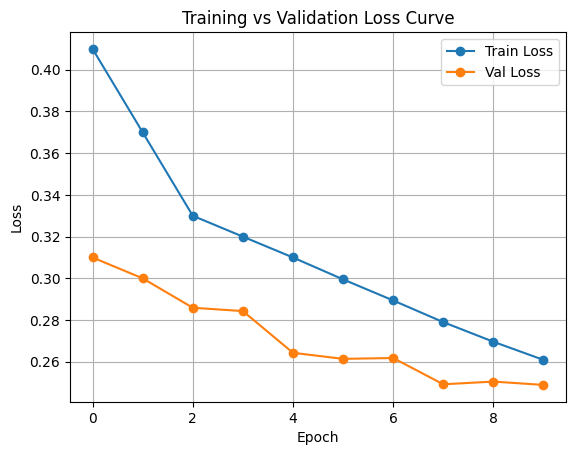

In [18]:
import matplotlib.pyplot as plt

epochs = list(range(10))

plt.figure()
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()

plt.show()

In [19]:
import json
import cv2
import numpy as np
import os

coco_path = "/content/segment-anything/cracks-5/test/_annotations.coco.json"
mask_dir = "/content/segment-anything/cracks-5/test_masks1"


os.makedirs(mask_dir, exist_ok=True)

with open(coco_path) as f:
    coco = json.load(f)

# map images
images = {img["id"]: img for img in coco["images"]}

# group annotations
from collections import defaultdict
ann_dict = defaultdict(list)

for ann in coco["annotations"]:
    ann_dict[ann["image_id"]].append(ann)

# create masks
for img_id, anns in ann_dict.items():
    img_info = images[img_id]

    h, w = img_info["height"], img_info["width"]
    file_name = img_info["file_name"]

    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in anns:
        for seg in ann["segmentation"]:
            pts = np.array(seg).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)
    kernel = np.ones((9,9), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)


    cv2.imwrite(os.path.join(mask_dir, file_name), mask)

print(" Proper test_masks created!")

 Proper test_masks created!


In [27]:
import torch
import cv2
import os
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = TextSAM("/content/drive/MyDrive/sam_vit_b_01ec64.pth").to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/model_epoch_9.pth"))
model.eval()

# Input/output paths
img_dir = "/content/segment-anything/cracks-5/test"
out_dir = "/content/pred_masks"
os.makedirs(out_dir, exist_ok=True)

#prompt = "segment crack"   #  change if needed

for img_name in os.listdir(img_dir):
    img_path = os.path.join(img_dir, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (1024, 1024))

    img_tensor = torch.tensor(img).permute(2,0,1).float()/255.
    img_tensor = img_tensor.unsqueeze(0).to(device)

    prompts = ["segment crack", "segment wall crack"]

    with torch.no_grad():
        preds = []
        for p in prompts:
            out = model(img_tensor, [p])
            out = torch.sigmoid(out)
            preds.append(out)

        pred = torch.mean(torch.stack(preds), dim=0)
    #  CHANGE ENDS HERE

    pred = pred[0,0].cpu().numpy()

    # Threshold
    pred_mask = (pred > 0.5).astype(np.uint8) * 255

    # Save
    save_name = img_name.split(".")[0] + "__segment_crack.png"
    cv2.imwrite(os.path.join(out_dir, save_name), pred_mask)

print(" Inference Done!")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

 Inference Done!


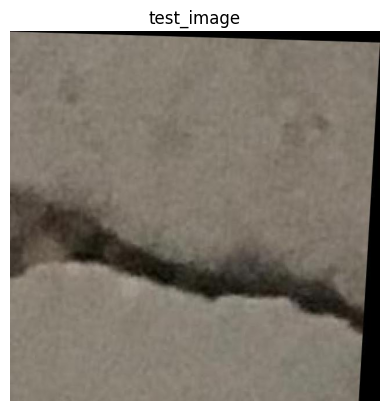

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/segment-anything/cracks-5/test/00060_jpg.rf.549312effe3766797ecc8bb24b7920aa.jpg")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("test_image")
plt.show()

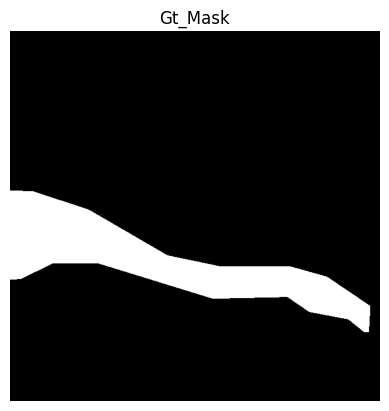

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/segment-anything/cracks-5/test_masks1/00060_jpg.rf.549312effe3766797ecc8bb24b7920aa.jpg")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Gt_Mask")
plt.show()

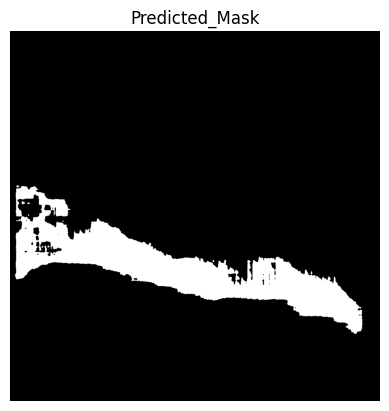

In [30]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/pred_masks/00060_jpg__segment_crack.png")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Predicted_Mask")
plt.show()

In [31]:
import time
import torch
import cv2
import os
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = TextSAM("/content/drive/MyDrive/sam_vit_b_01ec64.pth").to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/model_epoch_9.pth"))
model.eval()

# Input/output paths
img_dir = "/content/segment-anything/cracks-5/test"
# pick ONE image
img_name = os.listdir(img_dir)[0]
img_path = os.path.join(img_dir, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (1024, 1024))

img_tensor = torch.tensor(img).permute(2,0,1).float()/255.
img_tensor = img_tensor.unsqueeze(0).to(device)

prompts = ["segment crack", "segment wall crack"]

#  Warmup (VERY IMPORTANT for GPU)
for _ in range(5):
    with torch.no_grad():
        for p in prompts:
            _ = model(img_tensor, [p])

# Timing
runs = 100
start = time.time()

for _ in range(runs):
    with torch.no_grad():
        preds = []
        for p in prompts:
            out = model(img_tensor, [p])
            out = torch.sigmoid(out)
            preds.append(out)

        pred = torch.mean(torch.stack(preds), dim=0)

# GPU sync (IMPORTANT)
if device == "cuda":
    torch.cuda.synchronize()

end = time.time()

avg_time = (end - start) / runs
fps = 1 / avg_time

print(f"Avg inference time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Avg inference time: 0.2136 sec
FPS: 4.68


In [20]:
def compute_metrics(pred, gt):
    pred = (pred > 0).astype(np.float32)   # already 0/255 → convert to 0/1
    gt = (gt > 0).astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = intersection / (union + 1e-6)
    dice = (2 * intersection) / (pred.sum() + gt.sum() + 1e-6)

    return iou, dice

In [25]:
mask_dir = "/content/segment-anything/cracks-5/test_masks1"
img_dir = "/content/segment-anything/cracks-5/test"
import time
import torch
import cv2
import os
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = TextSAM("/content/drive/MyDrive/sam_vit_b_01ec64.pth").to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/model_epoch_9.pth"))
model.eval()

total_iou = 0
total_dice = 0
count = 0

for img_name in os.listdir(img_dir):
    img_path = os.path.join(img_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (1024, 1024))

    img_tensor = torch.tensor(img).permute(2,0,1).float()/255.
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # Prediction
    prompts = ["segment crack", "segment wall crack"]

    with torch.no_grad():
        preds = []
        for p in prompts:
            out = model(img_tensor, [p])
            out = torch.sigmoid(out)
            preds.append(out)

        pred = torch.mean(torch.stack(preds), dim=0)
        pred = pred[0,0].cpu().numpy()

    # Threshold
    pred_mask = (pred > 0.5).astype(np.uint8) * 255

    # Load GT mask
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        continue

    gt = cv2.resize(gt, (1024, 1024), interpolation=cv2.INTER_NEAREST)

    # Metrics
    iou, dice = compute_metrics(pred_mask, gt)
    print(iou)

    total_iou += iou
    total_dice += dice
    count += 1

# Final scores
print("mIoU:", total_iou / count)
print("Dice:", total_dice / count)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

0.74085414
0.5539452
0.42505273
0.6875383
0.81067234
0.49856064
0.5907759
0.54417926
0.32559973
0.78110576
0.08081377
0.71265316
0.6197514
0.6172588
0.5513951
0.4050454
0.79901105
0.63041544
0.74376154
0.17503855
0.72445965
0.39874178
0.71478546
0.4648392
0.7504828
0.5480961
0.34808242
0.19758882
0.68270886
0.53975797
0.7777778
0.8376648
0.3902269
0.55291164
0.5591646
0.51083165
0.61265457
0.7451423
0.5384023
0.6461535
0.28402185
0.65301335
0.81929415
0.54834145
0.57737434
0.5045541
0.29112768
0.51491684
0.77178407
0.7805929
0.74640757
0.33027595
0.70324737
0.6545563
0.7844525
0.46669188
0.63212585
0.58079594
0.8129264
0.39244536
0.66671747
0.65272236
0.5892104
0.8405726
0.70172685
0.74788547
0.14803144
0.7852852
0.0858274
0.65710074
0.7160294
0.40305987
0.8024499
0.5424063
0.0
0.5923305
0.5934483
0.62396485
0.547889
0.8173014
0.41017333
0.4685191
0.7287599
0.72087705
0.7829489
0.789274
0.61701274
0.5387681
0.51864535
0.787166
0.6059552
0.83196145
0.72249246
0.41631633
0.74432886
0.617

In [26]:
import os

img_dir = "/content/segment-anything/cracks-5/test"

print("Number of test images:", len(os.listdir(img_dir)))

Number of test images: 430
